# Setup a game

In [1]:
from ConnectN import ConnectN

game_setting = {'size':(6,6), 'N':4}
game = ConnectN(**game_setting)



In [2]:
game.move((0,1))
print(game.state)
print(game.player)
print(game.score)

[[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
-1
None


In [3]:
# player -1 move
game.move((0,0))
# player +1 move
game.move((1,1))
# player -1 move
game.move((1,0))
# player +1 move
game.move((2,1))

print(game.state)
print(game.player)
print(game.score)

[[-1.  1.  0.  0.  0.  0.]
 [-1.  1.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]]
-1
None


# Play a game interactively

In [4]:
%pip install ipympl
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
#%matplotlib notebook
%matplotlib ipympl

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc
from IPython.display import HTML
rc('animation', html='jshtml')

from Play import Play


gameplay=Play(ConnectN(**game_setting),
              player1=None,
              player2=None)

#HTML(gameplay.fig.to_jshtml())

# Initialize an AI to play the game
We need to define a policy for tic-tac-toe, that takes the game state as input, and outputs a policy and a critic

## Tentative Exercise:
Code up your own policy for training

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from math import *
import numpy as np
import random

'''
class Policy(nn.Module):

    def __init__(self):
        super(Policy, self).__init__()



        # solution
        self.conv = nn.Conv2d(1, 16, kernel_size=2, stride=1, bias=False)
        self.size = 2*2*16
        self.fc = nn.Linear(self.size,32)

        # layers for the policy
        self.fc_action1 = nn.Linear(32, 16)
        self.fc_action2 = nn.Linear(16, 9)

        # layers for the critic
        self.fc_value1 = nn.Linear(32, 8)
        self.fc_value2 = nn.Linear(8, 1)
        self.tanh_value = nn.Tanh()


    def forward(self, x):


        # solution
        y = F.relu(self.conv(x))
        y = y.view(-1, self.size)
        y = F.relu(self.fc(y))


        # the action head
        a = F.relu(self.fc_action1(y))
        a = self.fc_action2(a)
        # availability of moves
        avail = (torch.abs(x.squeeze())!=1).type(torch.FloatTensor)
        avail = avail.view(-1, 9)

        # locations where actions are not possible, we set the prob to zero
        maxa = torch.max(a)
        # subtract off max for numerical stability (avoids blowing up at infinity)
        exp = avail*torch.exp(a-maxa)
        prob = exp/torch.sum(exp)


        # the value head
        value = F.relu(self.fc_value1(y))
        value = self.tanh_value(self.fc_value2(value))
        return prob.view(3,3), value


policy = Policy()
policy_original = torch.load('6-6-4-pie.policy', weights_only=False)
policy.load_state_dict(policy_original.state_dict())
'''


class Policy(nn.Module):

    def __init__(self, game):
        super(Policy, self).__init__()

        # input = 6x6 board
        # convert to 5x5x8
        self.conv1 = nn.Conv2d(1, 16, kernel_size=2, stride=1, bias=False)
        # 5x5x16 to 3x3x32
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, bias=False)

        self.size=3*3*32

        # the part for actions
        self.fc_action1 = nn.Linear(self.size, self.size//4)
        self.fc_action2 = nn.Linear(self.size//4, 36)

        # the part for the value function
        self.fc_value1 = nn.Linear(self.size, self.size//6)
        self.fc_value2 = nn.Linear(self.size//6, 1)
        self.tanh_value = nn.Tanh()

    def forward(self, x):

        y = F.leaky_relu(self.conv1(x))
        y = F.leaky_relu(self.conv2(y))
        y = y.view(-1, self.size)

        # action head
        a = self.fc_action2(F.leaky_relu(self.fc_action1(y)))

        avail = (torch.abs(x.squeeze())!=1).type(torch.FloatTensor)
        avail = avail.contiguous().view(-1, 36)
        maxa = torch.max(a)
        exp = avail*torch.exp(a-maxa)
        prob = exp/torch.sum(exp)

        # value head
        value = self.tanh_value(self.fc_value2(F.leaky_relu( self.fc_value1(y) )))
        return prob.view(6,6), value

policy = Policy(game)
policy_original = torch.load('6-6-4-pie.policy', weights_only=False)
policy.load_state_dict(policy_original.state_dict())



/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.conv.Conv2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.linear.Linear' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.activation.Tanh' has changed. you can retrieve the original source code by accessing the object's source attribute or set `

<All keys matched successfully>

## Define a player that uses MCTS and the expert policy + critic to play a game

We've introduced a new parameter
$T$ = temperature

This tells us how to choose the next move based on the MCTS results

$$p_a = \frac{N_a^{\frac{1}{T}}}{\sum_a N_a^{\frac{1}{T}}}$$

$T \rightarrow 0$, we choose action with largest $N_a$.

In [7]:
import MCTS

from copy import copy
import random

def Policy_Player_MCTS(game):
    mytree = MCTS.Node(copy(game))
    print(policy)
    for _ in range(50):
        mytree.explore(policy)

    mytreenext, (v, nn_v, p, nn_p) = mytree.next(temperature=0.1)

    return mytreenext.game.last_move

def Random_Player(game):
    return random.choice(game.available_moves())


In [ ]:
%matplotlib ipympl

game = ConnectN(**game_setting)
print(game.state)
Policy_Player_MCTS(game)

# Play a game against the policy

In [7]:
from google.colab import output
output.enable_custom_widget_manager()

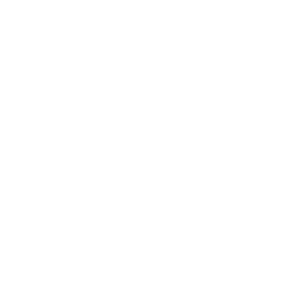

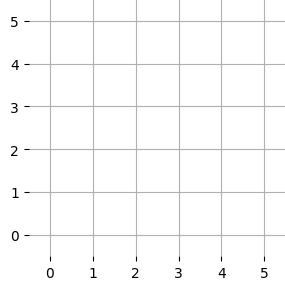

Policy(
  (conv1): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1), bias=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (fc_action1): Linear(in_features=288, out_features=72, bias=True)
  (fc_action2): Linear(in_features=72, out_features=36, bias=True)
  (fc_value1): Linear(in_features=288, out_features=48, bias=True)
  (fc_value2): Linear(in_features=48, out_features=1, bias=True)
  (tanh_value): Tanh()
)


/content/MCTS.py:68: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  return game.available_moves(), tinv(prob)[mask].view(-1), v.squeeze().squeeze()
/content/MCTS.py:159: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current.V = -float(v)


Policy(
  (conv1): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1), bias=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (fc_action1): Linear(in_features=288, out_features=72, bias=True)
  (fc_action2): Linear(in_features=72, out_features=36, bias=True)
  (fc_value1): Linear(in_features=288, out_features=48, bias=True)
  (fc_value2): Linear(in_features=48, out_features=1, bias=True)
  (tanh_value): Tanh()
)
Policy(
  (conv1): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1), bias=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (fc_action1): Linear(in_features=288, out_features=72, bias=True)
  (fc_action2): Linear(in_features=72, out_features=36, bias=True)
  (fc_value1): Linear(in_features=288, out_features=48, bias=True)
  (fc_value2): Linear(in_features=48, out_features=1, bias=True)
  (tanh_value): Tanh()
)
Policy(
  (conv1): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1), bias=False)
  (conv2): Conv2d(16, 32, kern

TypeError: 'NoneType' object is not callable

In [8]:
#%matplotlib notebook
%matplotlib ipympl

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc
from IPython.display import HTML
rc('animation', html='jshtml')

from Play import Play

gameplay=Play(ConnectN(**game_setting),
              player1=None,
              player2=Policy_Player_MCTS)

# Training Loop

In [ ]:
# initialize our alphazero agent and optimizer
import torch.optim as optim

game=ConnectN(**game_setting)
policy = Policy()
optimizer = optim.Adam(policy.parameters(), lr=.01, weight_decay=1.e-4)

## Tenative exercise:
code up the alphazero loss function, defined to be
$$L = \sum_t \left\{ (v^{(t)}_\theta - z)^2  - \sum_a p^{(t)}_a \log \pi_\theta(a|s_t) \right\} + \textrm{constant}$$
I added a constant term $\sum_t \sum_a p^{(t)}\log p^{(t)}$ so that when $v_\theta^{(t)} = z$ and $p^{(t)}_a = \pi_\theta(a|s_t)$, $L=0$, this way we can have some metric of progress.

In [ ]:
# train our agent

from collections import deque
import MCTS

episodes = 400
outcomes = []
losses = []

!pip install progressbar
import progressbar as pb
widget = ['training loop: ', pb.Percentage(), ' ',
          pb.Bar(), ' ', pb.ETA() ]
timer = pb.ProgressBar(widgets=widget, maxval=episodes).start()

for e in range(episodes):

    mytree = MCTS.Node(ConnectN(**game_setting))
    vterm = []
    logterm = []

    while mytree.outcome is None:
        for _ in range(50):
            mytree.explore(policy)

        current_player = mytree.game.player
        mytree, (v, nn_v, p, nn_p) = mytree.next()
        mytree.detach_mother()



        '''
        # solution
        # compute prob* log pi
        loglist = torch.log(nn_p)*p

        # constant term to make sure if policy result = MCTS result, loss = 0
        constant = torch.where(p>0, p*torch.log(p),torch.tensor(0.))
        logterm.append(-torch.sum(loglist-constant))

        vterm.append(nn_v*current_player)
        '''

    # we compute the "policy_loss" for computing gradient
    outcome = mytree.outcome
    outcomes.append(outcome)

    '''
    solution
    # loss = torch.sum( (torch.stack(vterm)-outcome)**2 + torch.stack(logterm) )
    optimizer.zero_grad()
    '''
    loss.backward()
    losses.append(float(loss))
    optimizer.step()

    if (e+1)%50==0:
        print("game: ",e+1, ", mean loss: {:3.2f}".format(np.mean(losses[-20:])),
              ", recent outcomes: ", outcomes[-10:])
    del loss

    timer.update(e+1)


timer.finish()




In [ ]:
# plot your losses

import matplotlib.pyplot as plt

% matplotlib notebook
plt.plot(losses)
plt.show()


# Play a game against your alphazero agent !

In [ ]:
% matplotlib notebook

# as first player
gameplay=Play(ConnectN(**game_setting),
              player1=None,
              player2=Policy_Player_MCTS)


In [ ]:
% matplotlib notebook

# as second player

gameplay=Play(ConnectN(**game_setting),
              player2=None,
              player1=Policy_Player_MCTS)
